<a href="https://colab.research.google.com/github/rpark3/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [3]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [4]:
n_bootstrap = 10000
n = len(driver_tips)
median_bootstrap = np.empty(n_bootstrap)

for i in range(n_bootstrap):
  sample = np.random.choice(driver_tips, size=n, replace=True)
  median_bootstrap[i] = np.median(sample)

ci_low, ci_high = np.percentile(median_bootstrap, [2.5, 97.5])
print(f"95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}]")

95% Confidence Interval: [0.27, 1.36]


In [5]:
np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)
observed_difference = np.mean(control) - np.mean(treatment)
print(f"Observed Difference: {observed_difference:.2f}")

Observed Difference: 2.26


In [6]:
combined = np.concatenate([control,treatment])
iterations = 5000
simulated_diffs = []

for _ in range(iterations):
  shuffled = np.random.permutation(combined)
  pseudo_group1 = shuffled[:500]
  pseudo_group2 = shuffled[500:]
  simulated_diffs.append(np.mean(pseudo_group1) - np.mean(pseudo_group2))

simulated_diffs = np.array(simulated_diffs)

p_val = np.mean(np.abs(simulated_diffs) >= np.abs(observed_difference))
print("P-value:", p_val)
if p_val >= 0.05:
    print("CONCLUSION: Not Significant (p > 0.05).")
else:
    print("Conclusion: Significant.")

P-value: 0.0004
Conclusion: Significant.


In [8]:
df = pd.read_csv("swiftcart_loyalty.csv")

mean_subs = df[df['subscriber'] == 1]['post_spend'].mean()
mean_non_subs = df[df['subscriber'] == 0]['post_spend'].mean()
Diff_means = mean_subs - mean_non_subs
print(f"Observed Difference: {Diff_means:.2f}")

Observed Difference: 17.57


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [23]:
X = df[["pre_spend", "account_age", "support_tickets"]]
Y = df['subscriber']

model = LogisticRegression()
model.fit(X, Y)
df['propensity_score'] = model.predict_proba(X)[:, 1]

subscribers = df[df['subscriber'] == 1]
non_subscribers = df[df['subscriber'] == 0]

Nearest_Neigh = NearestNeighbors(n_neighbors=1)
Nearest_Neigh.fit(non_subscribers[['propensity_score']])
distances, indices = Nearest_Neigh.kneighbors(subscribers[['propensity_score']])
matched_control = non_subscribers.iloc[indices.flatten()]

ATT = np.mean(matched_control['post_spend']) - np.mean(non_subscribers['post_spend'])

print(f"Average Treatment Effect on the Treated: {ATT:.2f}")

Average Treatment Effect on the Treated: 7.66


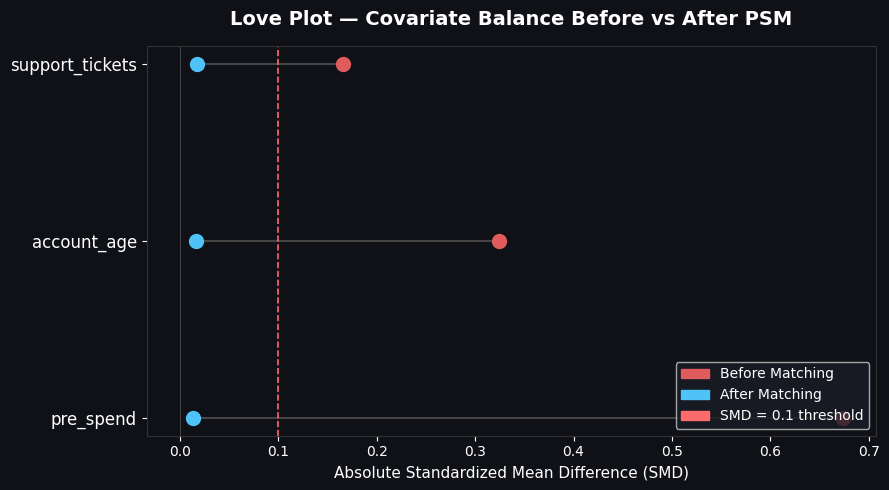

Saved: love_plot.png

=== SMD Summary ===
Feature                Before    After  Balanced?
------------------------------------------------
pre_spend               0.674    0.014      ✓ YES
account_age             0.324    0.016      ✓ YES
support_tickets         0.166    0.017      ✓ YES


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# ── Setup dataframes ───────────────────────────────────────────────────────
df = pd.read_csv('swiftcart_loyalty.csv')

covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

model = LogisticRegression()
model.fit(X, D)
df['propensity_score'] = model.predict_proba(X)[:, 1]

subs     = df[df['subscriber'] == 1]
non_subs = df[df['subscriber'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(non_subs[['propensity_score']])
indices = nn.kneighbors(subs[['propensity_score']])[1].flatten()
matched_control = non_subs.iloc[indices]

df_unmatched = df.copy()
df_matched   = pd.concat([subs, matched_control])

# ── Standardized Mean Difference function ─────────────────────────────────
def compute_smd(df, covariates):
    smds = {}
    treated = df[df['subscriber'] == 1]
    control = df[df['subscriber'] == 0]
    for col in covariates:
        diff   = treated[col].mean() - control[col].mean()
        pooled = np.sqrt((treated[col].std()**2 + control[col].std()**2) / 2)
        smds[col] = abs(diff / pooled)
    return smds

smd_before = compute_smd(df_unmatched, covariates)
smd_after  = compute_smd(df_matched,   covariates)

# ── Build Love Plot ────────────────────────────────────────────────────────
features   = list(smd_before.keys())
vals_before = [smd_before[f] for f in features]
vals_after  = [smd_after[f]  for f in features]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

# Threshold line
ax.axvline(x=0.1, color='#ff6b6b', linestyle='--', linewidth=1.2,
           label='SMD = 0.1 (balance threshold)')
ax.axvline(x=0.0, color='white',   linestyle='-',  linewidth=0.5, alpha=0.3)

# Plot points + connecting lines
y_pos = range(len(features))
for i, feat in enumerate(features):
    ax.plot([vals_before[i], vals_after[i]], [i, i],
            color='#444', linewidth=1.5, zorder=1)
    ax.scatter(vals_before[i], i, color='#e05c5c', s=100, zorder=2)
    ax.scatter(vals_after[i],  i, color='#4fc3f7', s=100, zorder=2)

# Labels & styling
ax.set_yticks(list(y_pos))
ax.set_yticklabels(features, color='white', fontsize=12)
ax.set_xlabel('Absolute Standardized Mean Difference (SMD)', color='white', fontsize=11)
ax.set_title('Love Plot — Covariate Balance Before vs After PSM',
             color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

legend = ax.legend(
    handles=[
        mpatches.Patch(color='#e05c5c', label='Before Matching'),
        mpatches.Patch(color='#4fc3f7', label='After Matching'),
        mpatches.Patch(color='#ff6b6b', label='SMD = 0.1 threshold'),
    ],
    facecolor='#1a1d27', labelcolor='white', fontsize=10, loc='lower right'
)

plt.tight_layout()
plt.savefig('love_plot.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: love_plot.png")

# ── SMD Table ─────────────────────────────────────────────────────────────
print("\n=== SMD Summary ===")
print(f"{'Feature':<20} {'Before':>8} {'After':>8} {'Balanced?':>10}")
print("-" * 48)
for f in features:
    balanced = "✓ YES" if smd_after[f] < 0.1 else "✗ NO"
    print(f"{f:<20} {smd_before[f]:>8.3f} {smd_after[f]:>8.3f} {balanced:>10}")